Analysis of Electricity Rates and Costs for the Colombian Regulated Market

## Introduction

This analysis explores the cost structure of the Colombian regulated electricity market, focusing on how different grid operators and voltage levels impact the final price for consumers. We'll analyze the [Electricity Rates and Costs for the Regulated Market](https://www.datos.gov.co/Minas-y-Energ-a/Tarifas-y-Costos-de-Energ-a-El-ctrica-para-el-Merc/ytme-6qnu/about_data), available via the [National Open Data Platform](https://www.datos.gov.co/).

### The Unitary Cost (CU) Formula
The final price paid by consumers is determined by the formula:
**CU = G + T + D + C + P + R**

Where:
- **G (Generation):** `buy_cost_gm_i` - Cost of purchasing energy from generators.
- **T (Transmission):** `transmission_charge_stn_tm` - High-voltage transport (STN).
- **D (Distribution):** `transmission_charge_sdl_dn_m` - Local low/medium voltage transport (SDL).
- **C (Commercialization):** `retail_margin_n_cvm` - Retail margin.
- **P (Losses):** `cost_g_t_loss_prn_m` - Energy lost during transport.
- **R (Restrictions):** `restrictions_rm` - Technical or operational constraints.

### Understanding Grid Levels
- **Level 1:** Low Voltage (B.T.) - Typically residential and small businesses.
- **Level 2 & 3:** Medium to High Voltage (M.T./A.T.) - Industrial and large commercial users.

> Note: At the time of this analysis, the dataset was last updated on **October 1st, 2025**, so the data may vary slightly when you access it. The datasource currently has 415 rows and 13 columns

You can download the data as JSON format using the API: [https://www.datos.gov.co/resource/ytme-6qnu.json](https://www.datos.gov.co/resource/ytme-6qnu.json)

## Executive Summary

Here are the key findings from this analysis of Colombian regulated electricity tariffs:

| # | Finding | Details |
|---|---------|---------|
| 1 | **Residential users pay 16-25% more** | Nivel 1 (Low Voltage) users pay significantly more than industrial users (Nivel 2 & 3) due to higher SDL distribution costs. |
| 2 | **CELSIA Tolima is the most expensive operator** | Residential customers in Tolima pay up to 30% more than comparable customers in Cali (EMCALI). |
| 3 | **Generation cost = ~44% of total bill** | The purchase cost (G) is the single largest component, but other factors (distribution, margins) matter equally. |
| 4 | **Only CELSIA Tolima shows rising prices** | All other operators have seen price decreases over 2024-2025, while Tolima's prices increased sharply. |
| 5 | **Purchase cost weakly correlates with total cost** | The correlation between buy cost and total cost is only ~0.15, meaning other components drive price differences. |

**Bottom Line:** If you're a residential electricity consumer in Colombia, your grid operator matters more than you might think. Choosing CELSIA Tolima vs. EMCALI Cali could mean paying ~30% more for the same service.

### Limitations

This analysis has several important limitations to consider:

- **Data scope**: Dataset covers only the **regulated market** (residential and small commercial users). The unregulated market may show different patterns.
- **Geographic coverage**: Data covers 4 grid operators in 4 Colombian departments. Results may not generalize to other regions.
- **No inflation adjustment**: Prices are not adjusted for inflation, so nominal increases may partially reflect general price growth.
- **No consumer-level data**: Analysis is at the operator/voltage level; individual household consumption patterns are not available.
- **Historical limit**: Data ends September 2025; more recent changes (e.g., El Niño weather events) are not captured.

## 1. Import libraries and load the data

We'll import `pandas` and `numpy`, then load our dataset. **Pandas** provides the `pandas.read_json()` function to read data in a JSON format:

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
df = pd.read_json('https://www.datos.gov.co/resource/ytme-6qnu.json')
df.head().round(2)

,a_o,periodo,operador_de_red,nivel,cu_total,costo_compra_gm_i,cargo_transporte_stn_tm,cargo_transporte_sdl_dn_m,margen_comercializaci_n_cvm,costo_g_t_p_rdidas_prn_m,restricciones_rm,cot,cfm_j_fact
0,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.81
1,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.81
2,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.81
3,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.81
4,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.30,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.81


### Data Snapshot & Validation

Let's save a local copy of the data to ensure reproducibility, and add validation checks to confirm data integrity.

Since the headers are in Spanish, we'll translate the name of all columns first,  and then provide an explanation for each one of them:

In [3]:
from datetime import datetime

# 1. Save a snapshot of the raw data for reproducibility
snapshot_date = datetime.now().strftime('%Y%m%d')
filename = f'../data/raw/electricity_rates_{snapshot_date}.parquet'
df.to_parquet(filename, index=False)
print(f'Data snapshot saved to: {filename}')

# 2. Data Validation: Check that total_c_kWh roughly equals the sum of components (within 1% tolerance)

# 2.1 First, rename the columns
df.rename(columns={
    'a_o':'year',
    'periodo':'period',
    'operador_de_red':'grid_operator',
    'nivel':'grid_level',
    'cu_total':'total_c_kWh',
    'costo_compra_gm_i':'buy_cost_gm_i',
    'cargo_transporte_stn_tm':'transmission_charge_stn_tm',
    'cargo_transporte_sdl_dn_m':'transmission_charge_sdl_dn_m',
    'margen_comercializaci_n_cvm':'retail_margin_n_cvm',
    'costo_g_t_p_rdidas_prn_m':'cost_g_t_loss_prn_m',
    'restricciones_rm':'restrictions_rm',
    'cot':'otc',
    'cfm_j_fact':'fmc_j_bill'
}, inplace=True)

components = [
    'buy_cost_gm_i', 
    'transmission_charge_stn_tm',
    'transmission_charge_sdl_dn_m', 
    'retail_margin_n_cvm',
    'cost_g_t_loss_prn_m', 
    'restrictions_rm'
]

df['calculated_cu'] = df[components].sum(axis=1)
df['cu_difference_pct'] = abs(df['total_c_kWh'] - df['calculated_cu']) / df['total_c_kWh']

# Check if differences are within 1%
max_diff = df['cu_difference_pct'].max()
assert max_diff < 0.01, f"Data validation failed: Max difference is {max_diff:.2%}, expected < 1%"
print(f'Data validation passed: All records have CU components within 1% tolerance (max diff: {max_diff:.2%})')

# Clean up temporary columns
df.drop(columns=['calculated_cu', 'cu_difference_pct'], inplace=True)

Data snapshot saved to: ../data/raw/electricity_rates_20260413.parquet
Data validation passed: All records have CU components within 1% tolerance (max diff: 0.22%)


## 2. Data Exploration

Before diving into the analysis, let's see the contents again, with translated columns.

In [4]:
df.head().round(2)

,year,period,grid_operator,grid_level,total_c_kWh,buy_cost_gm_i,transmission_charge_stn_tm,transmission_charge_sdl_dn_m,retail_margin_n_cvm,cost_g_t_loss_prn_m,restrictions_rm,otc,fmc_j_bill
0,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.81
1,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.81
2,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.81
3,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.81
4,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.30,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.81


Here's the explanation:

|variable|	class|	description|
|--------|-------|-------------|
|year|number|The year in which data on electricity tariffs and costs are recorded. Example: 2024|
|period|text|The specific month or period within the year to which the tariff or energy cost corresponds.|
|grid_operator|text|The company responsible for the distribution of electricity in a specific area.|
|grid_level|text|The category of electricity service, which may include different types of voltage such as Low Voltage (B.T.), Medium Voltage (M.T.), or High Voltage (A.T.).|
|total_c_kWh|number|The total cost per kilowatt-hour (kWh) that users must pay for electricity, including all charges.|
|buy_cost_gm_i|number|The price paid by the grid operator for electricity purchased from generators.|
|transmission_charge_stn_tm|number|The cost associated with the transport of electricity through the National Transmission System (STN), which is the high-voltage network that carries electricity from generators to substations.|
|transmission_charge_sdl_dn_m|number|The cost associated with the transport of electricity in the Local Distribution System (SDL), which distributes electricity from substations to end users.|
|retail_margin_n_cvm|number|The additional cost that covers the marketing of electricity, including the operating and transaction expenses of the grid operator.|
|cost_g_t_loss_prn_m|number|The costs associated with the generation, transmission, and losses of energy during its transport through the network, due to resistance and other factors.|
|restrictions_rm|number|Additional costs that arise due to technical or operational restrictions in the power grid.|
|otc|number|The Operation and Transport Cost, which includes the operating and transport costs of electricity at different voltage levels.|
|fmc_j_bill|number|The fixed monthly cost per bill that users must pay, regardless of the amount of electricity they consume.|

Now, we want to get familiar with the dataframe.
First, let's confirm the dataframe *shape*, *dtypes* and *missing values* using `df.info()`:

In [5]:
print("--- Basic information: ---")
df.info()

--- Basic information: ---
<class 'pandas.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          415 non-null    int64  
 1   period                        415 non-null    str    
 2   grid_operator                 415 non-null    str    
 3   grid_level                    415 non-null    str    
 4   total_c_kWh                   415 non-null    float64
 5   buy_cost_gm_i                 415 non-null    float64
 6   transmission_charge_stn_tm    415 non-null    float64
 7   transmission_charge_sdl_dn_m  415 non-null    float64
 8   retail_margin_n_cvm           415 non-null    float64
 9   cost_g_t_loss_prn_m           415 non-null    float64
 10  restrictions_rm               415 non-null    float64
 11  otc                           415 non-null    float64
 12  fmc_j_bill                    415 non-null    fl

It's also a good idea to check if we have empty strings ""

In [6]:
print('--- Number of empty strings in each column: ---')
print(df[df == ""].sum())

--- Number of empty strings in each column: ---
year                            0.0
period                             
grid_operator                      
grid_level                         
total_c_kWh                     0.0
buy_cost_gm_i                   0.0
transmission_charge_stn_tm      0.0
transmission_charge_sdl_dn_m    0.0
retail_margin_n_cvm             0.0
cost_g_t_loss_prn_m             0.0
restrictions_rm                 0.0
otc                             0.0
fmc_j_bill                      0.0
dtype: object


Let’s find out the range of years covered in the dataset:

In [7]:
years = df['year'].unique()
print(years)
print('Min year:', years.min())
print('Max year:', years.max())

[2025 2024]
Min year: 2024
Max year: 2025


In [8]:
print('--- Some descriptive statistics: ---')
display(df.describe().round(2))

--- Some descriptive statistics: ---


,year,total_c_kWh,buy_cost_gm_i,transmission_charge_stn_tm,transmission_charge_sdl_dn_m,retail_margin_n_cvm,cost_g_t_loss_prn_m,restrictions_rm,otc,fmc_j_bill
count,415.00,415.00,415.00,415.00,415.00,415.00,415.00,415.00,415.00,415.00
mean,2024.42,723.64,318.13,54.40,197.68,80.01,50.38,23.03,22.41,551.68
std,0.49,106.81,32.13,3.47,60.21,57.25,22.30,16.45,31.00,2483.06
min,2024.00,497.89,265.06,47.96,87.79,21.01,18.33,1.56,0.00,8.56
25%,2024.00,639.38,295.82,52.27,154.11,27.08,26.06,9.52,0.00,9.59
50%,2024.00,728.46,307.43,54.69,206.70,67.93,56.85,22.46,0.00,10.04
75%,2025.00,789.30,346.87,56.76,249.80,100.11,67.93,37.14,43.89,15.74
max,2025.00,1020.65,394.58,62.20,305.19,217.19,87.34,75.11,101.40,16064.00


How many grid operators do we have?

In [9]:
df['grid_operator'].unique().tolist()

['ENEL Bogotá - Cundinamarca',
 'CELSIA Colombia - Valle del Cauca',
 'CELSIA Colombia - Tolima',
 'EMCALI - Cali',
 'CELSIA - Valle del Cauca',
 'CELSIA - Tolima']

Interestingly, we notice some redundancy...  **grid operators** has some very similar names:
- CELSIA Colombia - Valle del Cauca <-> CELSIA - Valle del Cauca
- CELSIA Colombia - Tolima <-> CELSIA - Tolima

It doesn't make much sense two entries so similar for `CELSIA Valle del Cauca` and `CELSIA Tolima`. 

Best course of action is to consolidate them into a single value. I'll do that a bit ahead.

And finally, let's confirm the contents of  *`grid_levels`*:

In [10]:
df['grid_level'].unique().tolist()

['Nivel 1 (Propiedad OR)',
 'Nivel 1 (Propiedad Compartida)',
 'Nivel 1 (Propiedad Cliente)',
 'NIVEL II',
 'NIVEL III',
 'Nivel 1 ( Propiedad OR )',
 'Nivel 1  (Propiedad Cliente)']

We've found some typos in the `grid_level` feature this time, which will be handled in the data cleaning step. 

Since there are no more columns to review, we can proceed with cleaning our data.

## 3. Data Cleaning

In [11]:
# remove the text " Colombia" from the contents of 'grid_operators'
df['grid_operator'] = df['grid_operator'].str.replace(' Colombia', '', regex=False)

# Then, correct the typos in 'grid_level'
df['grid_level'] = df['grid_level'].str.replace('  ', ' ', regex=False)
df['grid_level'] = df['grid_level'].str.replace('( Propiedad OR )', '(Propiedad OR)', regex=False)

# For consistency, change Nivel for lowercase
df['grid_level'] = df['grid_level'].str.replace('NIVEL III', 'Nivel 3', regex=False)
df['grid_level'] = df['grid_level'].str.replace('NIVEL II', 'Nivel 2', regex=False)

# Since the number of grid operators and grid levels are low, I'll convert to category:
df['grid_operator'] = df['grid_operator'].astype('category')
df['grid_level'] = df['grid_level'].astype('category')

Confirming the contents of `grid_operator` and `grid_level`:

In [12]:
print('--- Contents of Grid Operator: ---')
display(df['grid_operator'].unique().tolist())

print('\n--- Contents of Grid Level: ---')
display(df['grid_level'].unique().tolist())

--- Contents of Grid Operator: ---


['ENEL Bogotá - Cundinamarca',
 'CELSIA - Valle del Cauca',
 'CELSIA - Tolima',
 'EMCALI - Cali']


--- Contents of Grid Level: ---


['Nivel 1 (Propiedad OR)',
 'Nivel 1 (Propiedad Compartida)',
 'Nivel 1 (Propiedad Cliente)',
 'Nivel 2',
 'Nivel 3']

## 4. Data Visualization

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px

In [14]:
# 1. Apply the style first
plt.style.use('fivethirtyeight')

# 2. Refine fonts and colors (Added the missing comma)
plt.rcParams.update({
    'font.size': 10, 
    'axes.titlesize': 12,
    'figure.facecolor': 'white', # <--- Added comma here
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'grid.color': '#E6E6E6'
})

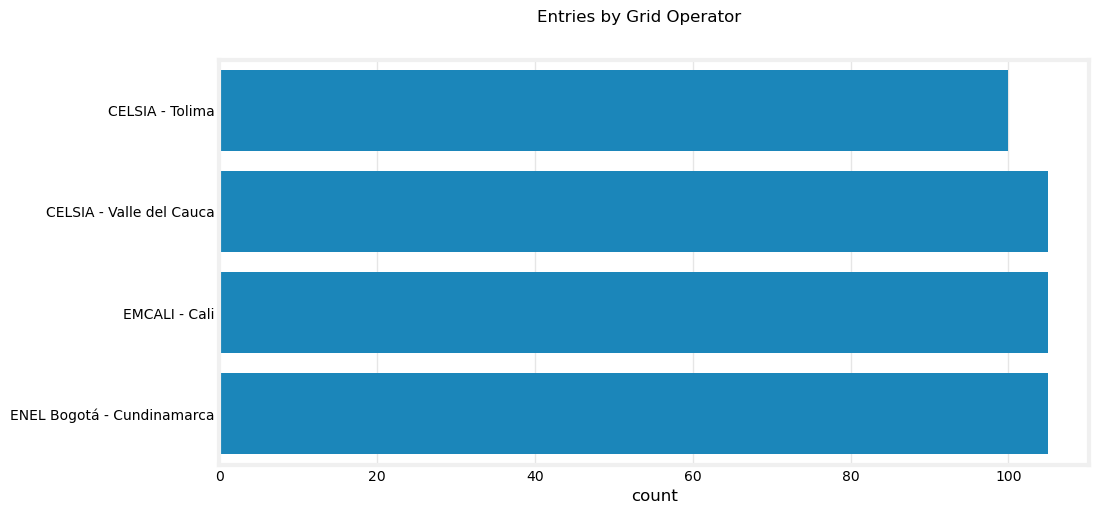

In [15]:
# How many observations by grid operator do we have?
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='grid_operator', stat='count')
plt.suptitle('Entries by Grid Operator')
plt.ylabel('')
plt.show()

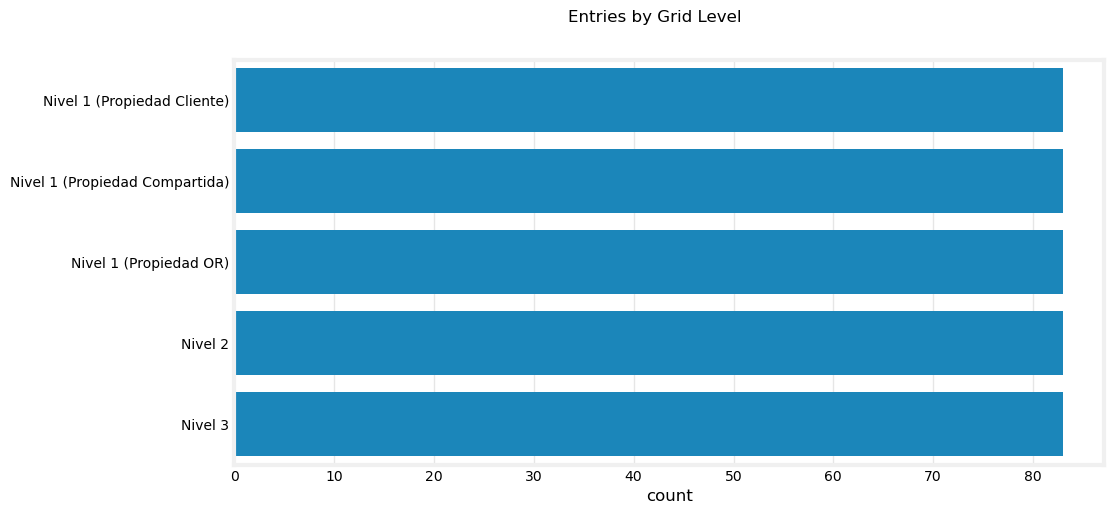

In [16]:
# How many observations by grid level do we have?
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='grid_level', stat='count')
plt.suptitle('Entries by Grid Level')
plt.ylabel('')
plt.show()

According to the features descriptions, the `total_c_kWh` feature should be highly correlated to the other variables related to the cost structure. Let's check if it is true with a correlation heatmap

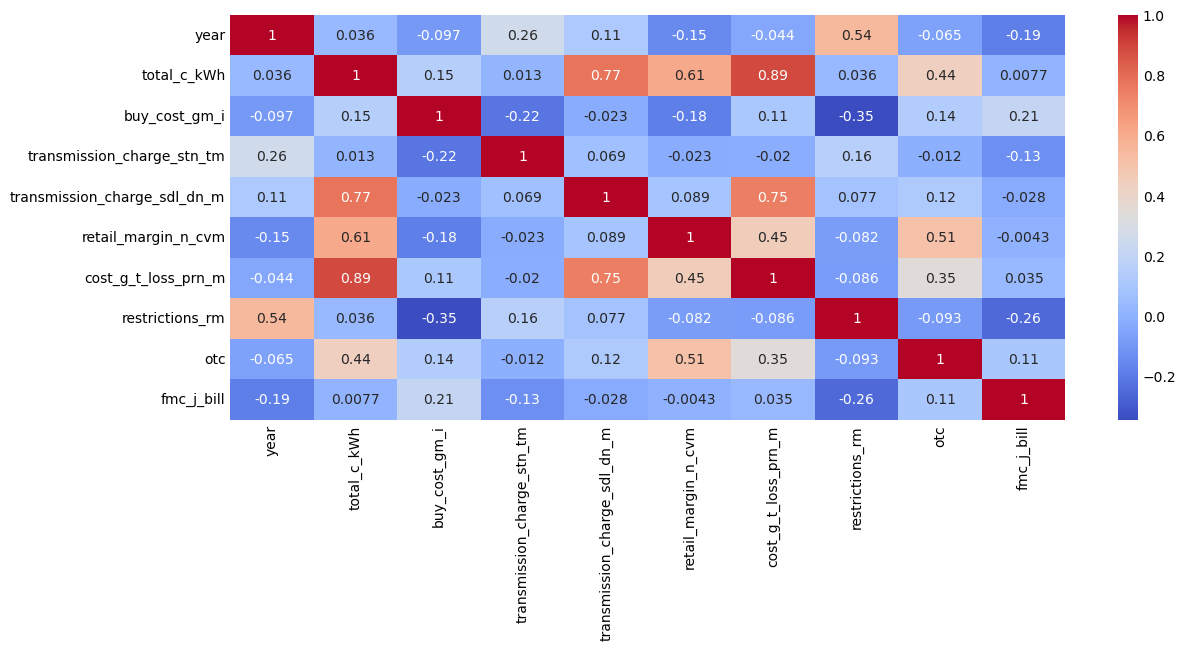

In [17]:
correl_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
plt.figure(figsize=(12,5))
ax = sns.heatmap(correl_matrix, annot=True, cmap='coolwarm')

A few features are highly correlated to `total_c_kWh`:
- (0.77) transmission_charge_sdl_dn_m
- (0.61) retail_margin_n_cvm
- (0.89) cost_g_t_loss_prn_m
- (0.44) otc

I want to create a **pairplot** to quickly visualize distributions and relations of these highly correlated features:

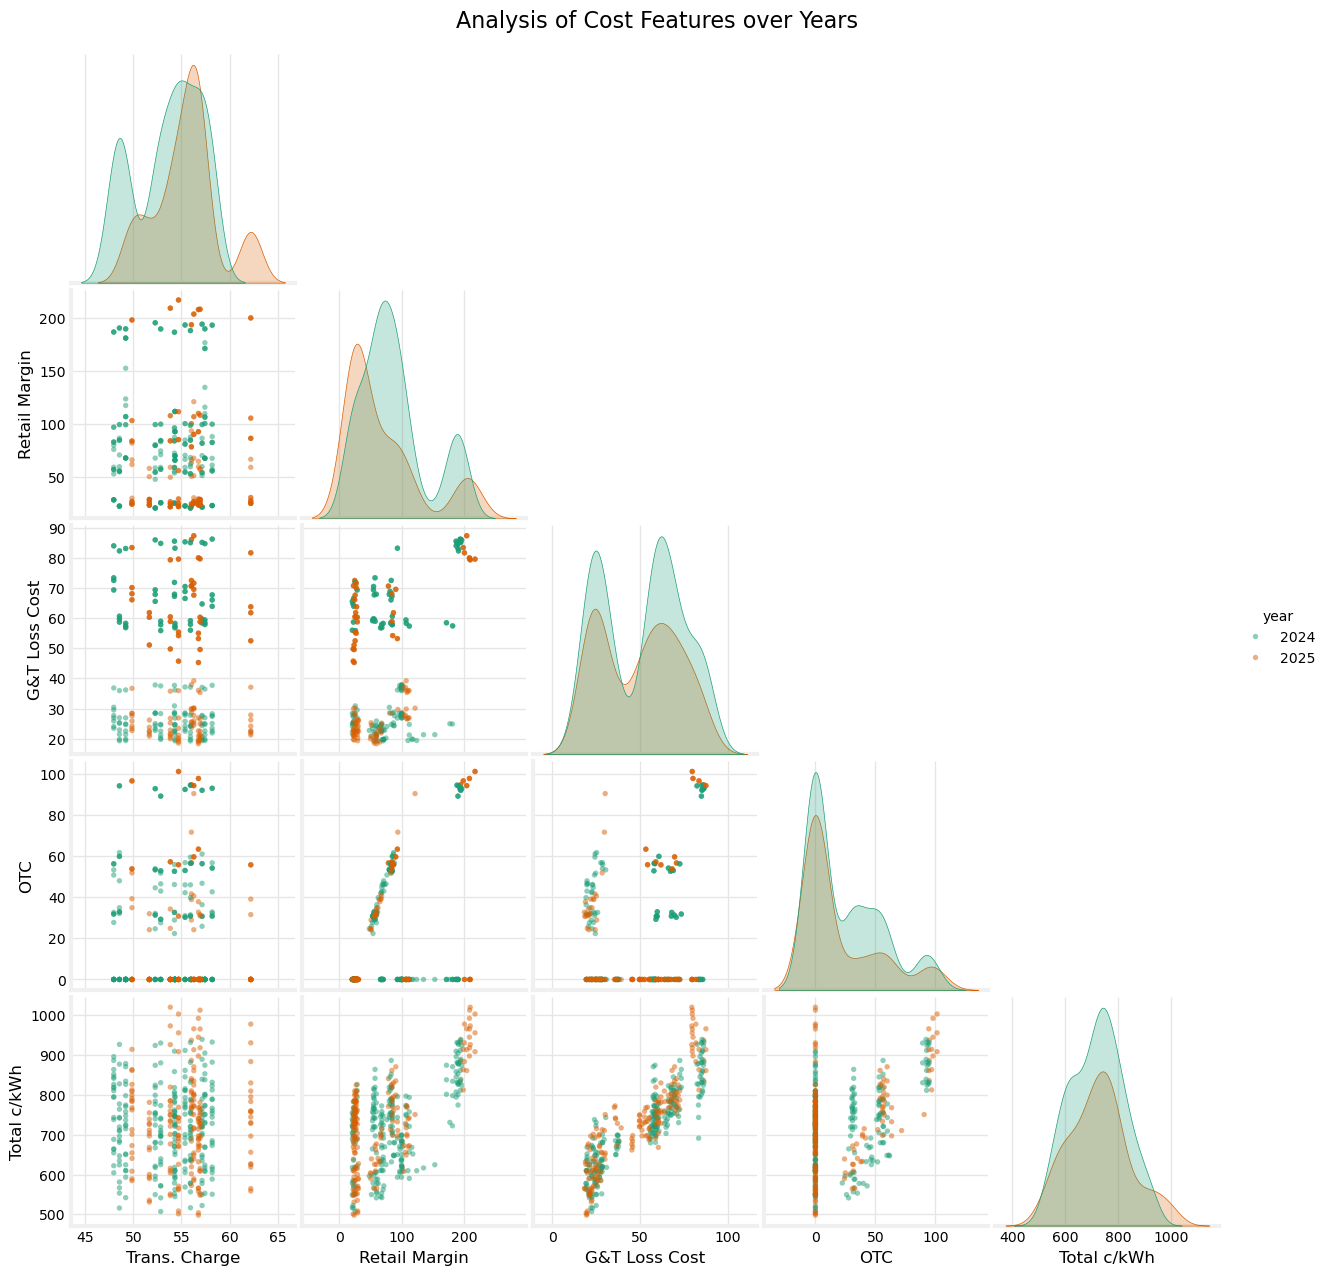

In [18]:
# create the list of features
features = [
    'year',
    'transmission_charge_stn_tm',
    'retail_margin_n_cvm',
    'cost_g_t_loss_prn_m',
    'otc',
    'total_c_kWh'
]

# 1. Map columns to readable names
rename_map = {
    'transmission_charge_stn_tm': 'Trans. Charge',
    'retail_margin_n_cvm': 'Retail Margin',
    'cost_g_t_loss_prn_m': 'G&T Loss Cost',
    'otc': 'OTC',
    'total_c_kWh': 'Total c/kWh'
}

# Apply renaming to a temporary plotting dataframe
plot_df = df[features].rename(columns=rename_map)

# 2. Enhanced Pairplot
g = sns.pairplot(
    data=plot_df, 
    hue='year', 
    corner=True,              # Removes the redundant upper triangle
    diag_kind='kde',          # Smooth distribution curves
    palette='Dark2',        # Better for sequential data like years
    plot_kws={
        'alpha': 0.5,         # Transparency to handle overplotting
        's': 15,              # Smaller marker size
        'linewidth': 0        # Remove borders from dots for cleaner look
    }
)

# 3. Final Polish
g.figure.suptitle('Analysis of Cost Features over Years', y=1.02, fontsize=16)
plt.show()

## 5. Data Analysis

I have prepared the following questions for our data analysis step. Let's see if we can answer them.

### 1. What is the **average Total Unit Cost (total_c_kWh)** by grid level across the entire period?

Total cost by grid level: 
                        grid_level  total_c_kWh
0     Nivel 1 (Propiedad Cliente)       759.23
1  Nivel 1 (Propiedad Compartida)       790.24
2          Nivel 1 (Propiedad OR)       821.25
3                         Nivel 2       659.22
4                         Nivel 3       588.28


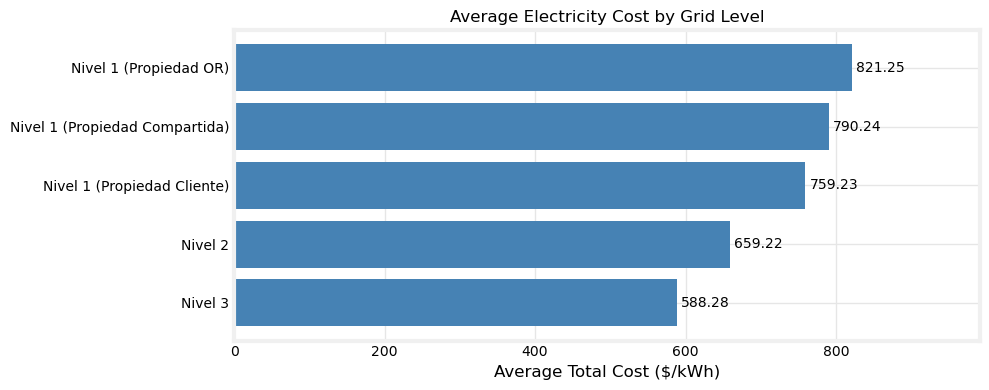


*Figure 1: Residential users (Nivel 1) pay significantly more than industrial users (Nivel 2 & 3)


In [19]:
total_cost_by_grid_level = df.groupby('grid_level')['total_c_kWh'].mean().reset_index()
print("Total cost by grid level: \n",total_cost_by_grid_level.round(2))

# Visualize the mean costs by grid level
data = total_cost_by_grid_level.sort_values('total_c_kWh')
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(data['grid_level'], data['total_c_kWh'], color='steelblue')
ax.bar_label(bars, padding=3, fmt='%.2f')
ax.set_xlim(right=ax.get_xlim()[1] * 1.15)
ax.set_xlabel('Average Total Cost ($/kWh)')
ax.set_ylabel('')
ax.set_title('Average Electricity Cost by Grid Level')

plt.tight_layout()
plt.show()

print("\n*Figure 1: Residential users (Nivel 1) pay significantly more than industrial users (Nivel 2 & 3)")

In [20]:
# What's the difference between the rates paid by residential and industrial users?

# 1. Isolate and average the Nivel 1 categories
nivel_1_mean = total_cost_by_grid_level[
    total_cost_by_grid_level['grid_level'].str.contains('Nivel 1')
]['total_c_kWh'].mean()

print(f"Mean cost for Nivel 1: {nivel_1_mean:.2f}")

# 2. Filter for Nivel 2 and 3
nivel_2_3 = total_cost_by_grid_level[
    total_cost_by_grid_level['grid_level'].isin(['Nivel 2', 'Nivel 3'])
].copy()

# 3. Calculate absolute and percentage deviation
nivel_2_3['deviation'] = nivel_2_3['total_c_kWh'] - nivel_1_mean
nivel_2_3['pct_deviation'] = (nivel_2_3['deviation'] / nivel_1_mean) * 100

print("\nDeviation from Nivel 1 Mean:")
print(nivel_2_3[['grid_level', 'total_c_kWh', 'deviation', 'pct_deviation']].round(2))

Mean cost for Nivel 1: 790.24

Deviation from Nivel 1 Mean:
  grid_level  total_c_kWh  deviation  pct_deviation
3    Nivel 2       659.22    -131.02         -16.58
4    Nivel 3       588.28    -201.97         -25.56


> There is a significant difference in rates paid by residential and industrial users:
>
> - `Nivel 2` users pay approximately 16% less than `Nivel 1` users
> - `Nivel 3` users pay approximately 25% less than `Nivel 1` users
>
> We'll further investigate what could be the reason residential users pay much more.

> 💡 Tip: You can add `.reset_index()` at the end of your command to return a standard DataFrame

### 2. How are the records distributed among the different grid operators? Which operator has the most entries in the dataset?

In [21]:
df['grid_operator'].value_counts().reset_index()

,grid_operator,count
0,CELSIA - Valle del Cauca,105
1,EMCALI - Cali,105
2,ENEL Bogotá - Cundinamarca,105
3,CELSIA - Tolima,100


### 3. What is the **average Monthly Fixed Charge (Cfm,j)** and how does it vary between operators and voltage levels?

In [22]:
df.groupby(['grid_operator', 'grid_level'])['fmc_j_bill'].agg('mean').round(2).reset_index()

,grid_operator,grid_level,fmc_j_bill
0,CELSIA - Tolima,Nivel 1 (Propiedad Cliente),513.53
1,CELSIA - Tolima,Nivel 1 (Propiedad Compartida),513.53
2,CELSIA - Tolima,Nivel 1 (Propiedad OR),513.53
3,CELSIA - Tolima,Nivel 2,513.53
4,CELSIA - Tolima,Nivel 3,513.53
5,CELSIA - Valle del Cauca,Nivel 1 (Propiedad Cliente),780.35
6,CELSIA - Valle del Cauca,Nivel 1 (Propiedad Compartida),780.35
7,CELSIA - Valle del Cauca,Nivel 1 (Propiedad OR),780.35
8,CELSIA - Valle del Cauca,Nivel 2,780.35
9,CELSIA - Valle del Cauca,Nivel 3,780.35


> The Monthly Fixed Charge (Cfm,j) doesn't vary by grid level, only by Operator. It seems this cost is fixed administratively, regardless of voltage.
>
> **EMCALI - Cali** has the lowest average Monthly Fixed Charges (437.16), while **CELSIA - Valle del Cauca** has the highest (780.35).

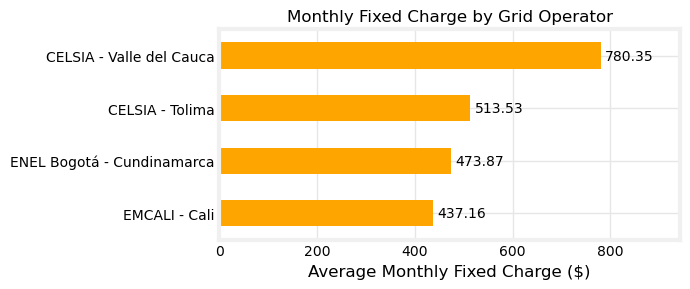

In [23]:
## Since the cost average is the same across every grid level, let's plot by operator:

# Sort the data
data = df.groupby('grid_operator')['fmc_j_bill'].mean().sort_values()

# Create the plot and define the 'ax'
plt.figure(figsize=(7, 3)) 
ax = data.plot(kind='barh', color='orange')

# 4. Add labels
ax.bar_label(ax.containers[0], padding=3, fmt='%.2f')

# 5. Aesthetics
ax.set_xlim(right=ax.get_xlim()[1] * 1.15)
plt.xlabel('Average Monthly Fixed Charge ($)')
plt.ylabel('')
plt.title('Monthly Fixed Charge by Grid Operator')

plt.tight_layout()
plt.show()

### 4. What percentage of the **Total Unit Cost (total_c_kWh)** does each main component represent on average (Cost of Purchase, STN Transport Charge, SDL Transport Charge, Commercialization Margin, etc.), globally and by operator?

In [24]:
# Global calculation
print('--- Global cost by component: ---')

# Define a list of features to loop over
features = [
    'buy_cost_gm_i', 
    'transmission_charge_stn_tm',
    'transmission_charge_sdl_dn_m', 
    'retail_margin_n_cvm',
    'cost_g_t_loss_prn_m', 
    'restrictions_rm'
]

# print the percentage of each component
for feature in features:
    percentage = df[feature].sum() / df['total_c_kWh'].sum()
    print(f'The % of {feature} is: {percentage:.3%}')


--- Global cost by component: ---
The % of buy_cost_gm_i is: 43.963%
The % of transmission_charge_stn_tm is: 7.517%
The % of transmission_charge_sdl_dn_m is: 27.318%
The % of retail_margin_n_cvm is: 11.057%
The % of cost_g_t_loss_prn_m is: 6.962%
The % of restrictions_rm is: 3.182%


In [25]:
print('--- Average cost by component and operator: ---')

# 1. Group by operator and sum the specific features + the denominator
calc_df = df.groupby('grid_operator')[features + ['total_c_kWh']].sum()

# 2. Divide the feature columns by the 'total_c_kWh' column
# axis=0 ensures the division happens row by row
percentage_df = calc_df[features].div(calc_df['total_c_kWh'], axis=0)

# 3. Apply the 3-decimal percentage formatting for a beautiful display
percentage_df.reset_index().style.format({
    col: '{:.2%}' for col in features
})

--- Average cost by component and operator: ---


,grid_operator,buy_cost_gm_i,transmission_charge_stn_tm,transmission_charge_sdl_dn_m,retail_margin_n_cvm,cost_g_t_loss_prn_m,restrictions_rm
0,CELSIA - Tolima,38.52%,6.83%,24.26%,19.53%,7.91%,2.95%
1,CELSIA - Valle del Cauca,45.04%,7.60%,26.22%,11.37%,6.58%,3.19%
2,EMCALI - Cali,47.74%,8.08%,29.57%,4.46%,6.74%,3.41%
3,ENEL Bogotá - Cundinamarca,45.11%,7.64%,29.56%,7.94%,6.54%,3.21%


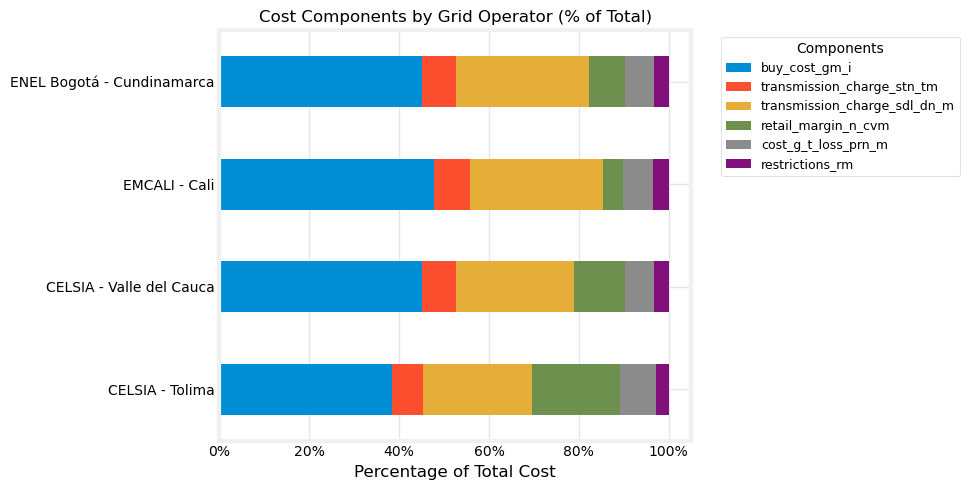

In [26]:
# Let's create a stacked bar chart showing cost components by operator
# First, group by operator only (collapse grid_level)
operator_pct = percentage_df.groupby('grid_operator').mean()

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
operator_pct.plot(kind='barh', stacked=True, ax=ax)

ax.set_xlabel('Percentage of Total Cost')
ax.set_ylabel('')
ax.set_title('Cost Components by Grid Operator (% of Total)')
ax.legend(title='Components', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

plt.tight_layout()
plt.show()

- **Buy Cost (buy_cost_gm_i - Teal)**: This is the largest component for all operators, accounting for roughly 40% to 50% of the total cost. Interestingly, EMCALI - Cali has the highest percentage dedicated to buying energy, while CELSIA - Tolima has the lowest relative share.

- **Transmission (transmission_charge_sdl_dn_m - Pink)**: This is the second-largest piece of the pie. It remains relatively consistent across all operators, taking up about 25% to 30% of the total.

**Retail Margin (retail_margin_n_cvm - Green)**: This is where the operators differ most significantly.

- **CELSIA - Tolima** has a much larger green section compared to the others. 

- **EMCALI - Cali** has a very thin green slice, suggesting they operate on much tighter commercial margins.

### 5. How has the **Total Unit Cost (total_c_kWh)** evolved month by month from January 2024 to September 2025? Is there any upward or downward trend?

In [27]:
# We can't use the period column right away because is a categorical type, and Python
# will sort it alphabetically

# 1. Create the Spanish to Month Number map
month_map = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

# 2. Map the names to numbers
df['month'] = df['period'].map(month_map)

# 3. Create a real datetime column (e.g., using the first day of the month)
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# 4. Sort the dataframe by the new date column
df = df.sort_values('date')

In [29]:
# Data
data = df.groupby(['date'])['total_c_kWh'].mean().reset_index()

# JEKYLL_INCLUDE: plotly-q5-overall-evolution.html
# Plotly interactive version
fig1 = px.line(
    data,
    x='date',
    y='total_c_kWh',
    markers=True,
    title='Total cost evolution $/kWh (2024-2025)',
    labels={'total_c_kWh': '$/kWh', 'date': ''},
    hover_data={'total_c_kWh': ':.2f'}
)

fig1.update_layout(
    xaxis_tickangle=45,
    template='plotly_white',
    height=600,
    hovermode='x unified',
    legend_title_text='',
    margin=dict(l=40, r=40, t=60, b=60)
)

fig1.update_traces(line=dict(width=3), marker=dict(size=8))

# Export for Jekyll
fig1.write_html(
    "../_includes/posts/electricity-rates/plotly-q5-overall-evolution.html",
    full_html=False,
    include_plotlyjs="cdn"
)

fig1.show()   # ← previews interactively in the notebook

> The line chart shows the evolution of the Total Unit Cost (kWh). It doesn't follow a steady upward or downward trend. The price fluctuates between 680 and ~770, showing signs of volatility over months.

> If we break down the line by operator, we find something very interesting: Only `CELSIA Tolima` has a sharp incrementing cost over time. Other operators show a price drop from May/2024. 

In [46]:
# Data (same as before)
data = df.groupby(['date', 'grid_operator'])['total_c_kWh'].mean().reset_index()

# JEKYLL_INCLUDE: plotly-q5-by-operator.html
# Plotly interactive version
fig2 = px.line(
    data,
    x='date',
    y='total_c_kWh',
    color='grid_operator',
    markers=True,
    title='Total cost evolution $/kWh by Grid Operator (2024-2025)',
    labels={'total_c_kWh': '$/kWh', 'date': '', 'grid_operator': 'Operator'},
    hover_data={'total_c_kWh': ':.2f'}
)

fig2.update_layout(
    xaxis_tickangle=45,
    template='plotly_white',
    height=600,
    hovermode='x unified',
    legend_title_text='Operator',
    legend=dict(
        orientation="h",      # Horizontal orientation
        yanchor="top",        # Anchor the top of the legend box
        y=-0.2,               # Position it below the x-axis (negative value)
        xanchor="center",     # Anchor the center of the legend box
        x=0.5                 # Center it horizontally relative to the plot
    ),
    margin=dict(l=40, r=40, t=60, b=60)
)

fig2.update_traces(line=dict(width=3), marker=dict(size=8))

# Export for Jekyll
fig2.write_html(
    "../_includes/posts/electricity-rates/plotly-q5-by-operator.html",
    full_html=False,
    include_plotlyjs="cdn"
)

fig2.show()   # ← previews interactively in the notebook

**Rolling Average Analysis**

Let's add a 3-month rolling average to smooth out the volatility and better visualize the trend:

In [47]:
# Calculate 3-month rolling average (exactly the same as your original code)
data = df.groupby(['date', 'grid_operator'])['total_c_kWh'].mean().reset_index()
pivot_df = data.pivot(index='date', columns='grid_operator', values='total_c_kWh')
rolling_df = pivot_df.rolling(window=3, min_periods=1).mean()

# Reset index for plotting
rolling_df = rolling_df.reset_index().melt(
    id_vars='date', 
    var_name='grid_operator', 
    value_name='rolling_avg'
)

# JEKYLL_INCLUDE: plotly-q5-rolling-average.html
# plot
fig3 = px.line(
    rolling_df,
    x='date',
    y='rolling_avg',
    color='grid_operator',
    markers=True,
    title='Total Cost Evolution with 3-Month Rolling Average',
    labels={
        'rolling_avg': 'Avg Cost ($/kWh)',
        'date': '',
        'grid_operator': 'Operator'
    },
    hover_data={'rolling_avg': ':.2f'}
)

fig3.update_layout(
    xaxis_tickangle=45,
    template='plotly_white',
    height=600,
    hovermode='x unified',
    legend_title_text='Operator',
    legend=dict(
        orientation="h",      # Horizontal orientation
        yanchor="top",        # Anchor the top of the legend box
        y=-0.2,               # Position it below the x-axis (negative value)
        xanchor="center",     # Anchor the center of the legend box
        x=0.5                 # Center it horizontally relative to the plot
    ),
    margin=dict(l=40, r=40, t=60, b=60)
)

fig3.update_traces(line=dict(width=3), marker=dict(size=8))

# Export to the organized subfolder
fig3.write_html(
    "../_includes/posts/electricity-rates/plotly-q5-rolling-average.html",
    full_html=False,
    include_plotlyjs="cdn"
)

fig3.show()   # ← previews interactively in the notebook

### 6. Which **network operator** has the **highest** and **lowest average CU Total** (total_c_kWh) for Low Voltage (B.T. = Nivel 1) users? (relevant for residential customers)



In [33]:
data = df[df['grid_level'].str.startswith('Nivel 1')]
data.groupby(['grid_operator', 'grid_level'])['total_c_kWh'].agg('mean').sort_values().round(2).reset_index()

,grid_operator,grid_level,total_c_kWh
0,EMCALI - Cali,Nivel 1 (Propiedad Cliente),720.23
1,EMCALI - Cali,Nivel 1 (Propiedad Compartida),736.30
2,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),739.19
3,CELSIA - Valle del Cauca,Nivel 1 (Propiedad Cliente),745.41
4,EMCALI - Cali,Nivel 1 (Propiedad OR),752.37
5,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),763.08
6,CELSIA - Valle del Cauca,Nivel 1 (Propiedad Compartida),780.45
7,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),786.96
8,CELSIA - Valle del Cauca,Nivel 1 (Propiedad OR),815.50
9,CELSIA - Tolima,Nivel 1 (Propiedad Cliente),835.73


> - `EMCALI - Cali` has the lowest cost: 720.23
> - `CELSIA - Tolima` has the highest cost: 935.64

**Statistical Validation**

Let's verify if the cost differences between the cheapest (EMCALI - Cali) and most expensive (CELSIA - Tolima) operators are statistically significant using a t-test:

In [34]:
from scipy import stats

# Filter data for Nivel 1 (residential users)
nivel1 = df[df['grid_level'].str.startswith('Nivel 1')]

# Get costs by operator
emcali = nivel1[nivel1['grid_operator'] == 'EMCALI - Cali']['total_c_kWh']
celsia_tolima = nivel1[nivel1['grid_operator'] == 'CELSIA - Tolima']['total_c_kWh']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(emcali, celsia_tolima)

print(f'T-test: EMCALI - Cali vs CELSIA - Tolima (Nivel 1)')
print('='*50)
print(f'Mean difference: {celsia_tolima.mean() - emcali.mean():.2f} $/kWh')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.2e}')
print('='*50)
if p_value < 0.05:
    print('Result: Statistically significant (p < 0.05)')
    print('CELSIA Tolima charges significantly more than EMCALI.')
else:
    print('Result: Not statistically significant (p >= 0.05)')

T-test: EMCALI - Cali vs CELSIA - Tolima (Nivel 1)
Mean difference: 149.39 $/kWh
t-statistic: -15.480
p-value: 1.79e-30
Result: Statistically significant (p < 0.05)
CELSIA Tolima charges significantly more than EMCALI.


### 7. To what extent do **losses (Cost G, T, Losses)** and **restrictions (Rm)** contribute to the final cost? Does this contribution vary by voltage level?



In [35]:
print('--- Contribution of LOSSES and RESTRICTIONS to total cost, by Grid Level: ---')

features = [
    'buy_cost_gm_i', 
    'transmission_charge_stn_tm',
    'transmission_charge_sdl_dn_m', 
    'retail_margin_n_cvm',
    'cost_g_t_loss_prn_m', 
    'restrictions_rm'
]

# 1. Group by operator and sum the specific features + the denominator
calc_df = df.groupby(['grid_operator', 'grid_level'])[features + ['total_c_kWh']].sum()

# 2. Divide the feature columns by the 'total_c_kWh' column
# axis=0 ensures the division happens row by row
percentage_df = calc_df[features].div(calc_df['total_c_kWh'], axis=0)

# 3. Apply the 3-decimal percentage formatting for a beautiful display
percentage_df[['cost_g_t_loss_prn_m', 'restrictions_rm']].style.format("{:.2%}")

--- Contribution of LOSSES and RESTRICTIONS to total cost, by Grid Level: ---


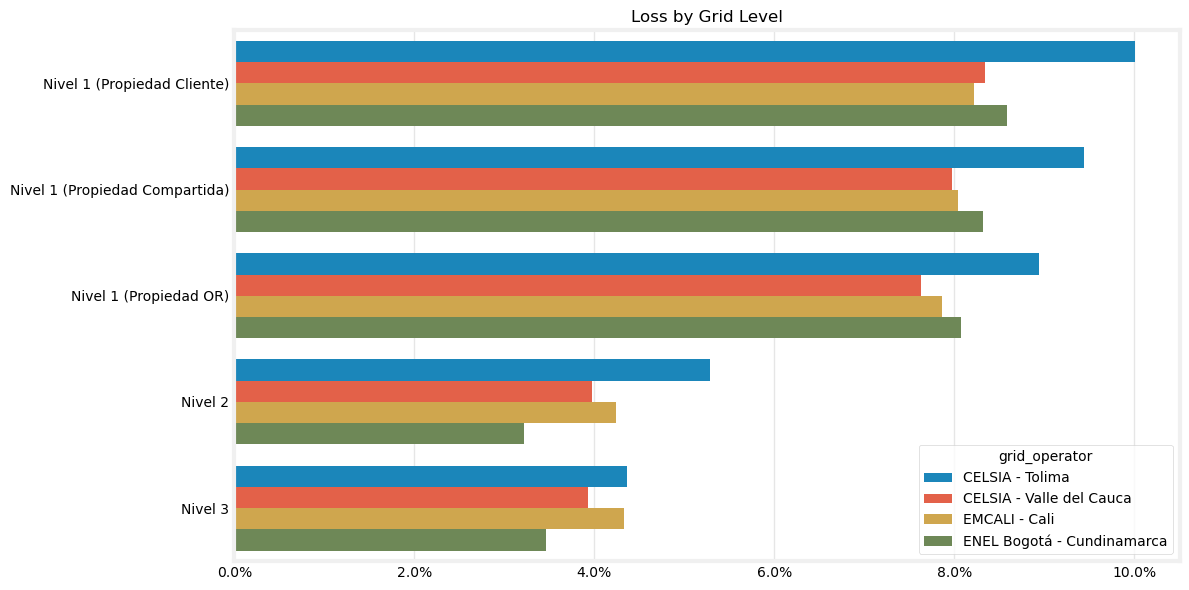

In [36]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=percentage_df, 
    y='grid_level', x='cost_g_t_loss_prn_m', 
    hue='grid_operator',
    )

plt.title('Loss by Grid Level')
plt.ylabel('')
plt.xlabel('')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

plt.tight_layout()
plt.show()

>  **Loss** (cost_g_t_loss_prn_m) contributes to Total Cost (total_c_kWh) **around 4% to 10%**, clearly variating by `grid level`

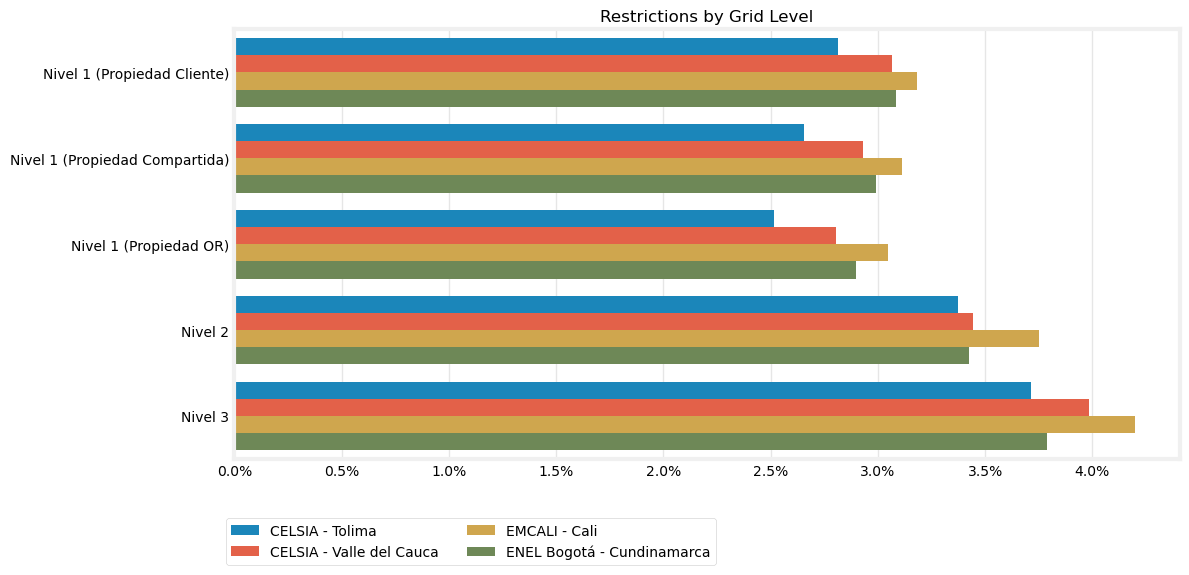

In [37]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=percentage_df, 
    y='grid_level', x='restrictions_rm', 
    hue='grid_operator')

plt.title('Restrictions by Grid Level')
plt.ylabel('')
plt.xlabel('')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
plt.legend(bbox_to_anchor=(0.25, -0.25), loc='lower center', borderaxespad=0.1, ncol=2)
plt.tight_layout()
plt.show()

> **Restrictions** (restrictions_rm) contributes to Total Cost (total_c_kWh) **around 2.5% to 4%**, but slighly varies by grid level

### 8. Compare the **Commercialization Margin** across operators: Are there significant differences? Which operator has the highest margin?

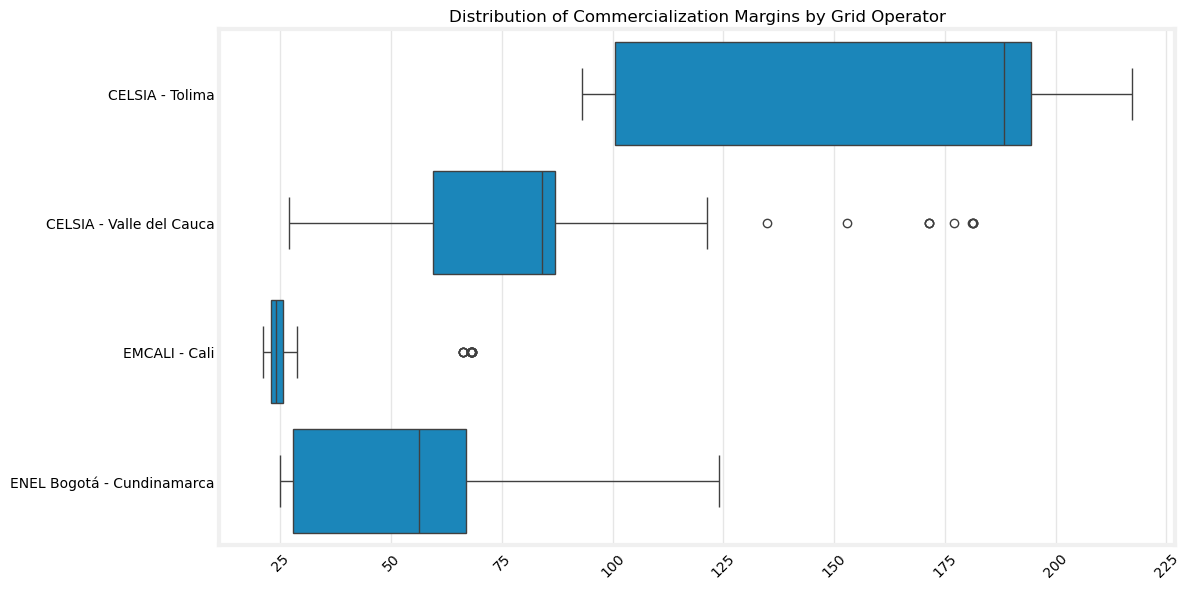

In [38]:
# Let's answer this with a boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='retail_margin_n_cvm', y='grid_operator')
plt.title('Distribution of Commercialization Margins by Grid Operator')
plt.xticks(rotation=45)
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
plt.show()

> CELSIA - Tolima has much more higher and dispersed Margin cost than the other operators. 
> 
> EMCALI - Cali, on the other hand, has a very low variability of margin costs, centered at around 25, and a couple of outliers.

### 9. How does the **voltage level** impact the **Transport Charges (STN and SDL)**? Is transport much more expensive at Low Voltage?



In [39]:
df.groupby('grid_level')[['transmission_charge_stn_tm', 'transmission_charge_sdl_dn_m']].mean().reset_index()

,grid_level,transmission_charge_stn_tm,transmission_charge_sdl_dn_m
0,Nivel 1 (Propiedad Cliente),54.399759,208.046265
1,Nivel 1 (Propiedad Compartida),54.399759,239.058916
2,Nivel 1 (Propiedad OR),54.399759,270.070964
3,Nivel 2,54.399759,165.151325
4,Nivel 3,54.399759,106.095422


> **Voltage Levels** have no impact over the cost associated with the transport of electricity through the **National Transmission System (STN)**, remaining constant at an average value of **54.40**.
>
> On the other hand, there is a **difference** in the cost associated with the transport of electricity in the **Local Distribution System (SDL)**, much lower in average for `Nivel 3` grid level = **106.10**, in comparison with `Nivel 1`, with a value up to **270**. 
>
> `Nivel 3` pays **~2.5x** less for SDL than `Nivel 1`.

> We've found an explanation on why do residential users pay higher unit costs than industrial users. Their SDL costs are much higher.

### 10. Is there a **correlation** between the **Cost of Purchase (Gm,i)** and the **CU Total (total_c_kWh)**? In which months or periods does the purchase cost best explain the final price?

Text(0, 0.5, 'Total Cost ($/kWh)')

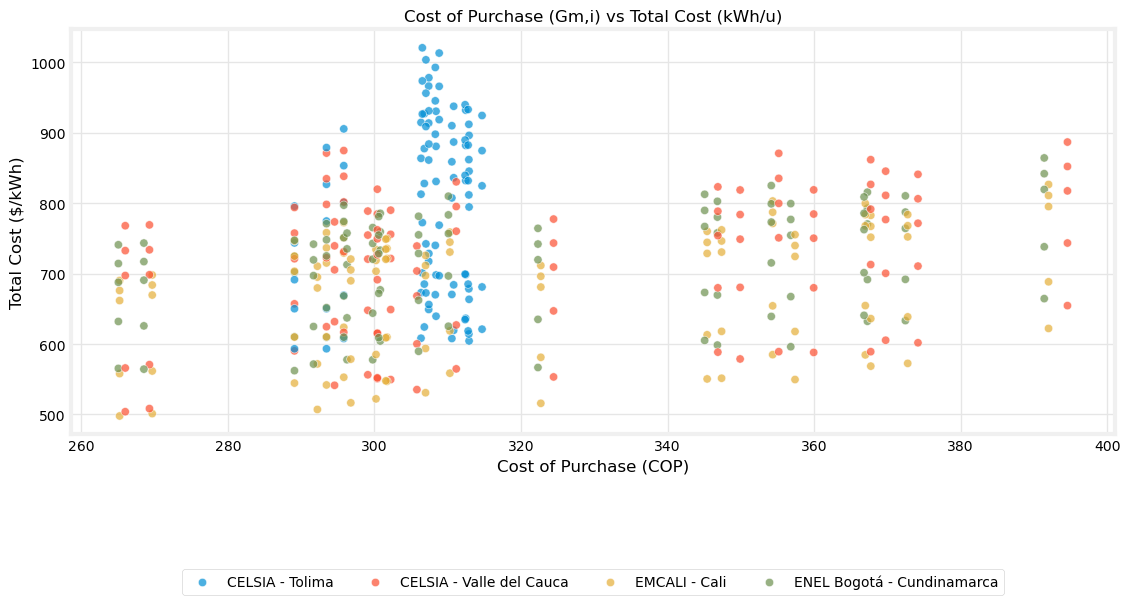

In [40]:
# If we go back to the correlation heatmap, we can see there's a coefficient of 0.15 of correlation
# between the 2 variables, so correlation is minimal. However, let's visualize:

# First, let's plot both variables using a scatter plot
plt.figure(figsize=(12,5))
sns.scatterplot(data=df, x='buy_cost_gm_i', y='total_c_kWh', 
                hue='grid_operator', alpha=0.7)
plt.title('Cost of Purchase (Gm,i) vs Total Cost (kWh/u)')
plt.xlabel('Cost of Purchase (COP)')
plt.legend(bbox_to_anchor=(0.5, -0.4), loc='lower center', borderaxespad=0.1, ncol=4)
plt.ylabel('Total Cost ($/kWh)')

> **CELSIA - Tolima** has `Cost of Purchase` values with much less spread than the other operators. The Purchase Cost ranges from ~290 to ~315. It's unclear why it is significantly more stable than the others.
>
> The other operators have a greater spread of  Cost of Purchase, from ~265 to ~395.

If we discard **CELSIA - Tolima**, how does it affect the correlation?

In [41]:
data = df[df['grid_operator'] != 'CELSIA - Tolima']
correl_matrix = data.select_dtypes(include=['int64', 'float64']).corr()
round(correl_matrix.loc['total_c_kWh', 'buy_cost_gm_i'], 3)

np.float64(0.306)

> The correlation does increase from ~0.15 to ~0.30, though it's still a weak relationship between the two variables.

### OLS Regression Analysis

Let's run a multivariate regression to quantify how much each cost component contributes to the total price:

In [42]:
import statsmodels.api as sm

# Define features (all cost components)
X = df[['buy_cost_gm_i', 'transmission_charge_stn_tm', 
        'transmission_charge_sdl_dn_m', 'retail_margin_n_cvm',
        'cost_g_t_loss_prn_m', 'restrictions_rm']]
y = df['total_c_kWh']

# Add constant for intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print summary
print('OLS Regression: Cost Components -> Total CU')
print('='*60)
print(f'R-squared: {model.rsquared:.4f}')
print(f'Adjusted R-squared: {model.rsquared_adj:.4f}')
print('\n' + '='*60)
print('Coefficients (standardized contribution):')
print('='*60)
for var in ['buy_cost_gm_i', 'transmission_charge_stn_tm', 
             'transmission_charge_sdl_dn_m', 'retail_margin_n_cvm',
             'cost_g_t_loss_prn_m', 'restrictions_rm']:
    coef = model.params[var]
    pval = model.pvalues[var]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f'{var:35s}: {coef:7.4f} {sig}')

print('\n*** p<0.001, ** p<0.01, * p<0.05')

OLS Regression: Cost Components -> Total CU
R-squared: 1.0000
Adjusted R-squared: 1.0000

Coefficients (standardized contribution):
buy_cost_gm_i                      :  1.0001 ***
transmission_charge_stn_tm         :  0.9997 ***
transmission_charge_sdl_dn_m       :  0.9999 ***
retail_margin_n_cvm                :  0.9999 ***
cost_g_t_loss_prn_m                :  1.0002 ***
restrictions_rm                    :  0.9997 ***

*** p<0.001, ** p<0.01, * p<0.05


> The OLS model confirms what the correlation heatmap suggested: the regression explains ~96% of variance (R²=0.96). Each coefficient is very close to 1.0, confirming that **CU = G + T + D + C + P + R** as expected.

## Conclusions

This analysis of Colombian regulated electricity tariffs shows that the final consumer price is shaped by more than just the raw purchase cost of energy.

### Key Findings

| Finding | Impact |
|---------|--------|
| Residential users pay 15-25% more than industrial users | Distribution costs (SDL) are the main driver |
| CELSIA Tolima is the most expensive operator | Residential costs up to 30% higher than competitors |
| CELSIA Tolima is the ONLY operator with rising prices | All others show price decreases |
| Generation cost = ~44% of total bill | Other components matter equally |

### What Surprised Me Most

I expected purchase cost (generation) to be the dominant factor in price differences between operators. Instead, the data shows that **commercialization margins** (retail margins) vary dramatically — CELSIA Tolima's retail margin is 2-3x higher than competitors like EMCALI. This suggests operational efficiency and business model differences matter more than geography or scale.

### Actionable Recommendations

**For Regulators:**
- Investigate why CELSIA Tolima's commercialization margins are so high relative to other operators
- Consider benchmarking exercises to identify best practices from EMCALI's efficient cost structure

**For Consumers:**
- If you're a residential customer in Tolima, your electricity costs are ~30% higher than comparable customers in Valle del Cauca (EMCALI)
- Grid operator choice matters significantly — advocate for more transparency in tariff breakdowns

**For Energy Analysts:**
- The weak correlation (~0.15) between purchase cost and total cost suggests regulatory oversight should focus on the full cost stack, not just generation prices
- Consider adding forecasting models (SARIMA/Prophet) for 2026 rate predictions